# POKEMON PARTIE 1
# Etape 1 : définir le problème à résoudre
# Préconiser au dresseur de pokémon l'animal à utiliser lors d'un combat afin d'être le vainqueur


In [1]:
# Etape 2: Acquérir les données (télécharger pour vous)
import os

listeDeFichiers = os.listdir("data")

for fichier in listeDeFichiers:
    print(fichier)

combats.csv
dataset.csv
pokedex.csv
poke_type_chart.csv
tests.csv


In [2]:
# Etape 3: préparation des données
import numpy as np
import pandas as pd

nosPokemons = pd.read_csv("data/pokedex.csv")
# Affichage de la structure de nos données
# print(nosPokemons.columns.values)
# Affichage des 10 premieres lignes
# print(nosPokemons.head(10))

# Transformation de la colonne LEGENDAIRE en entier 0 = FAUX et 1= VRAI 
nosPokemons['LEGENDAIRE'] = nosPokemons['LEGENDAIRE'].apply(lambda x: x == 'TRUE' if isinstance(x, str) else x)
nosPokemons['LEGENDAIRE'] = nosPokemons['LEGENDAIRE'].astype(int)
print(nosPokemons['LEGENDAIRE'].head(800))

#Comptage du nombre d'observation et de features
print(nosPokemons.shape)

#Information sur le jeu de données
print(nosPokemons.info())

# Affichage du feature NOM avec un valeur null
print(nosPokemons[nosPokemons['NOM'].isnull()])

# Trouver le nom sur pokepedia.fr en connaissant l'ID 62
print(nosPokemons ['NOM'][61])
print(nosPokemons ['NOM'][63])

nosPokemons['NOM'][62]= "Colossinge"

0      0
1      0
2      0
3      0
4      0
      ..
795    1
796    1
797    1
798    1
799    1
Name: LEGENDAIRE, Length: 800, dtype: int32
(800, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   NUMERO                    800 non-null    int64 
 1   NOM                       799 non-null    object
 2   TYPE_1                    800 non-null    object
 3   TYPE_2                    414 non-null    object
 4   POINTS_DE_VIE             800 non-null    int64 
 5   NIVEAU_ATTAQUE            800 non-null    int64 
 6   NIVEAU_DEFENSE            800 non-null    int64 
 7    NIVEAU_ATTAQUE_SPECIALE  800 non-null    int64 
 8   NIVEAU_DEFENSE_SPECIALE   800 non-null    int64 
 9   VITESSE                   800 non-null    int64 
 10  GENERATION                800 non-null    int64 
 11  LEGENDAIRE                800 non-n

C:\Users\josue\AppData\Local\Temp\ipykernel_26348\66507403.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nosPokemons['NOM'][62]= "Colossinge"


In [3]:
# Etape 4: Observation données de combat
# charger données 
combats = pd.read_csv("data/combats.csv")

# Affichage des colonnes dataframes
print(combats.columns.values)

# Affichage des 10 premieres lignes
print(combats.head(10))

# Comptage du nombre de lignes et de colonnes
print(combats.shape)

# Informations sur le jeu de données
print(combats.info())



['POKEMON_PREMIER' 'POKEMON_SECOND' 'GAGNANT']
   POKEMON_PREMIER  POKEMON_SECOND  GAGNANT
0              266             298      298
1              702             701      701
2              191             668      668
3              237             683      683
4              151             231      151
5              657             752      657
6              192             134      134
7               73             545      545
8              220             763      763
9              302              31       31
(50000, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   POKEMON_PREMIER  50000 non-null  int64
 1   POKEMON_SECOND   50000 non-null  int64
 2   GAGNANT          50000 non-null  int64
dtypes: int64(3)
memory usage: 1.1 MB
None


In [4]:
# Etape 5 : Pour connaitre le pokemon performant il faut associer (combiner ou rajouter)
# les deux Dataframe Pokedex et combats

# Pour connaitre le nombre de combat mener par un pokemon il faut : 
# Nombre de pokemon au premier rang
nbFoisPremierePosition = combats.groupby('POKEMON_PREMIER').count()
print(nbFoisPremierePosition)

# Ex taille dataframe
#taillesDataframe = pd.DataFrame({"taille": [175, np.nan, 160, 170, 180]})
#print(taillesDataframe)

# Nombre de pokemon au deuxième rang
nbFoisSecondePosition = combats.groupby('POKEMON_SECOND').count()
print(nbFoisSecondePosition)

# Somme des deux calculs
nombreTotalDeCombats = nbFoisPremierePosition + nbFoisSecondePosition
print(nombreTotalDeCombats)

# Nombre de combat gagnés par pokemon
nombreDeVictoires = combats.groupby('GAGNANT').count()
print(nombreDeVictoires)

                 POKEMON_SECOND  GAGNANT
POKEMON_PREMIER                         
1                            70       70
2                            55       55
3                            68       68
4                            62       62
5                            50       50
...                         ...      ...
796                          49       49
797                          64       64
798                          60       60
799                          75       75
800                          61       61

[784 rows x 2 columns]
                POKEMON_PREMIER  GAGNANT
POKEMON_SECOND                          
1                            63       63
2                            66       66
3                            64       64
4                            63       63
5                            62       62
...                         ...      ...
796                          56       56
797                          67       67
798                          59  

In [5]:
# Etape 6: Agrégation

# Création d'une liste à partir d'une extraction pour obténir la liste 
# de pokemon 

listeAAgreger = combats.groupby('GAGNANT').count()
listeAAgreger.sort_index()

# Ajout des nombres de combats
listeAAgreger['NBR_COMBATS'] = nbFoisPremierePosition.GAGNANT + nbFoisSecondePosition.GAGNANT

# Ajout des nombres de victoires
listeAAgreger['NBR_VICTOIRES'] = nombreDeVictoires.POKEMON_PREMIER

# Calcul pourcentage de victoires
listeAAgreger['POURCENTAGE'] = nombreDeVictoires.POKEMON_PREMIER/(nbFoisPremierePosition.GAGNANT + nbFoisSecondePosition.GAGNANT)

# Affiche de la liste
print(listeAAgreger)

# Agrégation finale
nouveauPokedex = nosPokemons.merge(listeAAgreger, left_on='NUMERO', right_index= True, how='left')
print(nouveauPokedex)

         POKEMON_PREMIER  POKEMON_SECOND  NBR_COMBATS  NBR_VICTOIRES  \
GAGNANT                                                                
1                     37              37          133             37   
2                     46              46          121             46   
3                     89              89          132             89   
4                     70              70          125             70   
5                     55              55          112             55   
...                  ...             ...          ...            ...   
796                   39              39          105             39   
797                  116             116          131            116   
798                   60              60          119             60   
799                   89              89          144             89   
800                   75              75          121             75   

         POURCENTAGE  
GAGNANT               
1           0.278

In [6]:
# Etape 6: Train
print(nouveauPokedex.describe())

         NUMERO  POINTS_DE_VIE  NIVEAU_ATTAQUE  NIVEAU_DEFENSE  \
count  800.0000     800.000000      800.000000      800.000000   
mean   400.5000      69.258750       79.001250       73.842500   
std    231.0844      25.534669       32.457366       31.183501   
min      1.0000       1.000000        5.000000        5.000000   
25%    200.7500      50.000000       55.000000       50.000000   
50%    400.5000      65.000000       75.000000       70.000000   
75%    600.2500      80.000000      100.000000       90.000000   
max    800.0000     255.000000      190.000000      230.000000   

        NIVEAU_ATTAQUE_SPECIALE  NIVEAU_DEFENSE_SPECIALE     VITESSE  \
count                800.000000               800.000000  800.000000   
mean                  72.820000                71.902500   68.277500   
std                   32.722294                27.828916   29.060474   
min                   10.000000                20.000000    5.000000   
25%                   49.750000              

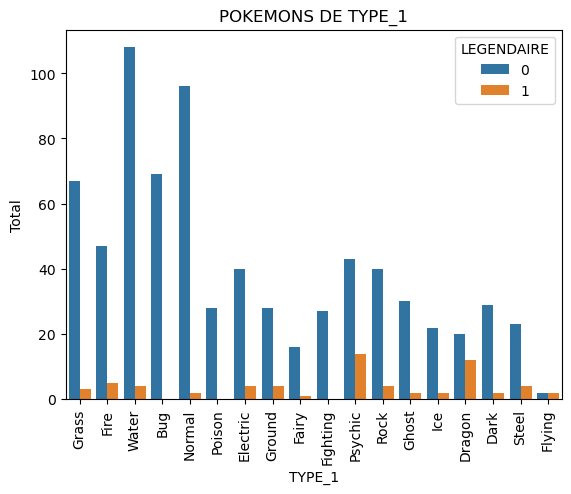

In [7]:
# Visualisation
# Répondra à la question : Quel pokemon doit posséder un dresseur
# POKEMON TYPE_1
import matplotlib.pyplot as plt
import seaborn as sns

axe_X = sns.countplot(x="TYPE_1", hue="LEGENDAIRE", data=nouveauPokedex)
plt.xticks(rotation= 90)
plt.xlabel('TYPE_1')
plt.ylabel('Total')
plt.title("POKEMONS DE TYPE_1")
plt.show()

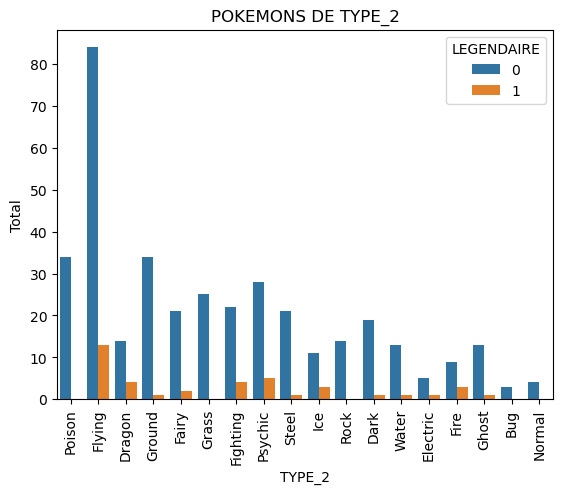

In [8]:
# POKEMON TYPE_2
import matplotlib.pyplot as plt
import seaborn as sns

axe_X = sns.countplot(x="TYPE_2", hue="LEGENDAIRE", data=nouveauPokedex)
plt.xticks(rotation= 90)
plt.xlabel('TYPE_2')
plt.ylabel('Total')
plt.title("POKEMONS DE TYPE_2")
plt.show()

In [9]:
# Type de pokemons gagnants et perdants
print(nouveauPokedex.groupby('TYPE_1').agg({"POURCENTAGE": "mean"}).sort_values(by="POURCENTAGE"))

          POURCENTAGE
TYPE_1               
Fairy        0.329300
Rock         0.404852
Steel        0.424529
Poison       0.433262
Bug          0.439006
Ice          0.439604
Grass        0.440364
Water        0.469357
Fighting     0.475616
Ghost        0.484027
Normal       0.535578
Ground       0.541526
Psychic      0.545747
Fire         0.579215
Dark         0.629726
Electric     0.632861
Dragon       0.633587
Flying       0.765061


C:\Users\josue\AppData\Local\Temp\ipykernel_26348\1726622928.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = nouveauPokedex.loc[:,['TYPE_1', 'POINTS_DE_VIE', 'NIVEAU_ATTAQUE', 'NIVEAU_DEFENSE', 'NIVEAU_DEFENSE_SPECIALE', 'VITESSE', 'LEGENDAIRE', 'POURCENTAGE']].corr()


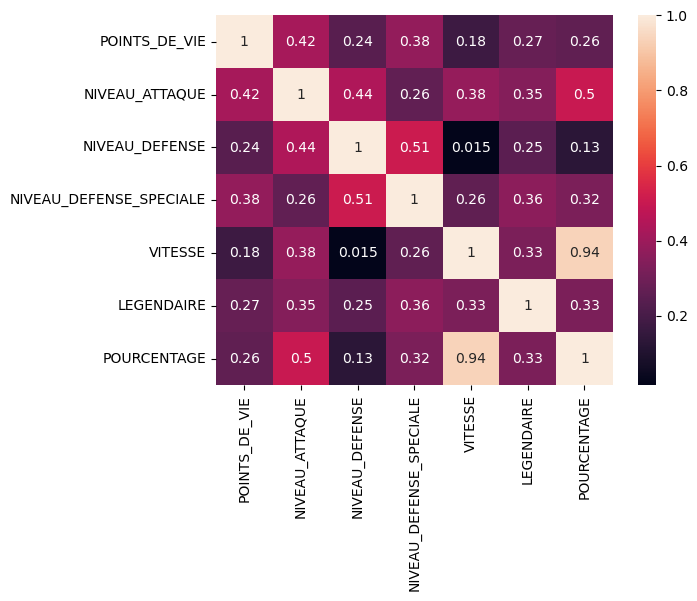

In [10]:
# Calcul de corrélation 
# Création de la visualisation

corr = nouveauPokedex.loc[:,['TYPE_1', 'POINTS_DE_VIE', 'NIVEAU_ATTAQUE', 'NIVEAU_DEFENSE', 'NIVEAU_DEFENSE_SPECIALE', 'VITESSE', 'LEGENDAIRE', 'POURCENTAGE']].corr()
sns.heatmap(corr, 
            xticklabels=corr.columns,
            yticklabels=corr.columns, annot=True)
plt.show()

In [11]:
# Préparation Dataset
# Sauvegarde du Dataframe Pokedex

dataset = nouveauPokedex
dataset.to_csv("data/dataset.csv", sep='\t')

# Chargement du dataset 
dataset = pd.read_csv("data/dataset.csv", delimiter='\t')

# Suppression des lignes ayant des valeurs manquantes
dataset = dataset.dropna(axis=0, how='any')

# Valeur pour X
X = dataset.iloc[:, 5:12].values

# Valeur pour Y
y = dataset.iloc[:, 17].values

In [12]:
# Import sckit learn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_APPRENTISSAGE, X_VALIDATION, Y_APPRENTISSAGE, Y_VALIDATION = train_test_split(X, y, test_size=0.2, random_state= 0) 

algorithme = LinearRegression()

algorithme.fit(X_APPRENTISSAGE, Y_APPRENTISSAGE)

predictions = algorithme.predict(X_VALIDATION)

precisions = r2_score(Y_VALIDATION, predictions)
print(predictions)
print(precisions)    

[0.93300971 0.29132888 0.84960723 1.08285284 0.59873467 0.39102016
 0.44513282 0.29092769 0.89773904 0.27805623 0.82824486 0.42547452
 0.88108203 0.45443062 0.34611029 0.46340086 0.37988368 0.63452108
 0.82209543 0.29936543 0.64520835 0.60425882 0.59266683 0.61447652
 0.36618714 0.4574185  0.37404953 0.87830983 0.9005281  0.43250568
 0.42305912 0.49682282 0.66028775 1.08060482 0.35878667 0.48511742
 0.45199742 0.24016572 0.77174327 0.16267367 0.34496357 0.66958312
 0.69772597 0.14801646 0.76212768 0.40499089 0.35554639 0.74417397
 0.66043329 0.4648638  0.57047635 0.83165959 0.36363439 0.61991302
 0.21610348 0.62539441 0.17948457 0.5842037  0.36648348 0.23180477
 0.54129002 0.13391301 0.49924438 0.57866291 0.40132835 0.74073528
 0.79084817 0.49277348 0.26462519 0.88566687 0.79022841 0.58370274
 0.21994514 0.43034698 0.46399355 0.65607869 0.98670278 0.07862785
 0.18602594 0.74318062 0.76465197]
0.900525380536642


In [13]:
# Import sckit learn
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

#X_APPRENTISSAGE, X_VALIDATION, Y_APPRENTISSAGE, Y_VALIDATION = train_test_split(X, y, test_size=0.2, random_state= 0) 

algorithme = DecisionTreeRegressor()

algorithme.fit(X_APPRENTISSAGE, Y_APPRENTISSAGE)

predictions = algorithme.predict(X_VALIDATION)

precisions = r2_score(Y_VALIDATION, predictions)
print(predictions)
print(precisions)    

[0.86153846 0.22377622 0.86923077 0.97478992 0.56097561 0.28205128
 0.3671875  0.26771654 0.88059701 0.45192308 0.70833333 0.40495868
 0.87254902 0.42335766 0.37931034 0.48387097 0.41791045 0.64705882
 0.77192982 0.26262626 0.64615385 0.56097561 0.4765625  0.625
 0.40495868 0.39568345 0.41176471 0.88793103 0.93043478 0.36734694
 0.48387097 0.5        0.4765625  0.94776119 0.45192308 0.57142857
 0.46212121 0.16778523 0.83739837 0.11851852 0.33613445 0.61654135
 0.728      0.44852941 0.8034188  0.4375     0.4214876  0.78461538
 0.72       0.28099174 0.4765625  0.86923077 0.30508475 0.56097561
 0.1557377  0.69333333 0.58064516 0.56097561 0.42537313 0.21929825
 0.54098361 0.19672131 0.52307692 0.55462185 0.42608696 0.7007874
 0.64935065 0.33333333 0.3125     0.87943262 0.7007874  0.57377049
 0.20143885 0.42537313 0.52985075 0.77443609 0.95934959 0.048
 0.1981982  0.87218045 0.64935065]
0.8501606295151068


In [14]:
# Import sckit learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

#X_APPRENTISSAGE, X_VALIDATION, Y_APPRENTISSAGE, Y_VALIDATION = train_test_split(X, y, test_size=0.2, random_state= 0) 

algorithme = RandomForestRegressor()

algorithme.fit(X_APPRENTISSAGE, Y_APPRENTISSAGE)

predictions = algorithme.predict(X_VALIDATION)
precisions_apprentissage = algorithme.score(X_APPRENTISSAGE, Y_APPRENTISSAGE)
precisions = r2_score(Y_VALIDATION, predictions)
print(predictions)
print(precisions) 

[0.86611458 0.23588865 0.87693234 0.96387228 0.57090763 0.35220113
 0.38402283 0.23608629 0.90315566 0.38031858 0.77596271 0.33761813
 0.87877167 0.41532598 0.35444178 0.48050309 0.39090039 0.63805899
 0.83413002 0.27261568 0.64138511 0.59050892 0.61162707 0.62463493
 0.33259257 0.44949949 0.38382221 0.88706548 0.90596083 0.37467423
 0.43915765 0.44388337 0.63204781 0.95434871 0.37130965 0.54341744
 0.46095065 0.21118709 0.82011425 0.1778333  0.24406373 0.65538361
 0.71326365 0.25183319 0.80099902 0.43965218 0.34576469 0.77414453
 0.72209229 0.36672691 0.58935272 0.84824158 0.34631101 0.57441476
 0.19413408 0.67974914 0.42289158 0.56533735 0.36932775 0.21750296
 0.56546989 0.15627816 0.54313527 0.60493273 0.39147315 0.80777752
 0.71620746 0.46480525 0.24799469 0.86990416 0.80681265 0.54562967
 0.17623464 0.38262709 0.53313971 0.69137757 0.95477532 0.0639178
 0.15339188 0.80502333 0.74165931]
0.9334369214056534


In [ ]:
# Sauvegarde du modèle
import joblib
fichier = 'modele/modele_pokemon.mod'
joblib.dump(algorithme, fichier)

['modele/modele_pokemon.mod']